Cross sectional Risk-Adjusted Momentum Strategy
--> Using Data from Binance to extract data from 2020-2026, with data from start of 2020 to end of 2023 being backtest data and start of 2024 to end of 2025 being validation data

--> The initial idea was to create a volume weighted time series momentum strategy, based on the research paper "Cryptocurrency Volume-Weighted TIme Series Momentum - Huang, Sangiorgi & Urquhart (SSRN, Dec 2024)"

--> However, while attempting to execute this strategy, I started to get confused with the execution between time series and cross sectional momentum strategies. On top of that, the added volume-weighted component made the strategy more complex, and created more noise within the results.

--> Therefore, since this is my first project, i decided instead to go with something simple and understandable, which is a basic cross sectional risk-adjusted momentum strategy.

--> A cross sectional risk-adjusted momentum strategy basically ranks a group of assets by their past returns, buying the 'winners' and shorting the 'losers'. It operates on the principle that relative outperformance tends to persist over intermediate time horizons

In [1]:
import statsmodels.api as sm
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import warnings

#datetime converts raw timestamps into human readable dates 
#timezone lets us label those dates as UTC explicitly
from datetime import datetime
from datetime import timezone

In [2]:
pd.set_option("future.no_silent_downcasting", True)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#connection to Binance's public API
client = bnb_client()

def get_binance_px(symbol, freq, start_ts='2020-01-01', end_ts='2024-01-01'):
    data = client.get_historical_klines(symbol,freq,start_ts, end_ts) #fetch candlestick (OHLCV) data, W/O column names
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns=columns)
    
    #Binance stores timestamps as milliseconds since Jan 1, 1970 (POSIX time)
    #Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    #/1000 to convert milliseconds to seconds
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 

# remove MATIC, EOS, XMR, XEM due to incomplete data --> did not have sufficient data for the validation test set
univ = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','DOTUSDT','XRPUSDT','LTCUSDT','LINKUSDT','XLMUSDT', 'BCHUSDT', 'TRXUSDT', 'XTZUSDT']

freq = '1h'

In [4]:
# Annotations from the volume-weighted component of the strategy that i attempted to incorporate
'''
# Vol and Vol Ratio calculation
### USE quote_volume / dollar notional volume so the weights are comparable across assets
def vol_ratio_calc():
    vol = {}
    for x in univ:
        data = get_binance_px(x,freq)
        vol[f'{x} Volume'] = data.set_index('open_time')['quote_volume'] # note the use of quote_volume!
    
    vol = pd.DataFrame(vol).astype(float)
    vol = vol.reindex(pd.date_range(vol.index[0], vol.index[-1], freq=freq))
    vol_ratio = vol.divide(vol.abs().sum(1),0)
    return vol_ratio, vol

vol_ratio, vol = vol_ratio_calc()

vol_ratio
'''

# Volume (rolling historical average)
'''
def volume_confirmation(vol):
    LOOKBACK_HOURS = 336 # 2-week formation window
    rolling_volume = vol.shift(1).rolling(window=LOOKBACK_HOURS).mean()
    
    # Momentum Interaction using vol
    vol_confirmed = (vol / rolling_volume)
    return vol_confirmed

vol_confirmed = volume_confirmation(vol)

vol_confirmed
'''

'''
# Signal
def final_signal(ts_signal, vol_confirmed, coin_cum_return):
    ts_signal.columns = univ
    vol_confirmed.columns = univ
    coin_cum_return.columns = univ
    combined_signal = ts_signal * vol_confirmed
    
    final_signal = combined_signal * coin_cum_return.abs()
    return final_signal
'''

'\n# Signal\ndef final_signal(ts_signal, vol_confirmed, coin_cum_return):\n    ts_signal.columns = univ\n    vol_confirmed.columns = univ\n    coin_cum_return.columns = univ\n    combined_signal = ts_signal * vol_confirmed\n    \n    final_signal = combined_signal * coin_cum_return.abs()\n    return final_signal\n'

In [5]:
# Return calculation
def return_cal():
    px = {}
    for x in univ:
        data = get_binance_px(x,freq)
        px[f'{x} Close'] = data.set_index('open_time')['close']

    px = pd.DataFrame(px).astype(float)
    px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
    ret = px.pct_change()
    return ret

# Building the lookback signal over the formation window
def lookback_signal(ret, LOOKBACK_HOURS, SKIP_HOURS):
    
    # Log returns add cleanly across time
    log_ret = np.log(1 + ret)
    
    # Coin cumulative log returns over the formation window
    coin_log_cum = (log_ret
        .shift(SKIP_HOURS) # exclude most recent 24 hours
        .rolling(window=LOOKBACK_HOURS, min_periods=168) # sum over 336 hours (2 weeks)
        .sum()
    )

    # Convert back to simple cumulative returns
    coin_cum_return = np.exp(coin_log_cum) - 1
    return coin_cum_return

# Calculating the realised volatility
def realised_vol_annual(ret):
    # Lookback window for estimating volatility
    # a short window reacts fast to regime changes but is noisy
    # a long window is stable but slow to notice that a coin just got wild
    # 21 days is a good middle ground
    VOL_WINDOW = 24 * 21    # 21 days of hourly data for the vol estimate
    ANNUALISE = np.sqrt(24 * 365)
    
    # Estimating realised volatility (.shift() used to ensure pos size established at a rebalance uses only previous available returns)
    ret.columns = univ
    realised_vol_hourly = ret.shift(1).rolling(window=VOL_WINDOW, min_periods=24).std()
    realised_vol_annual = realised_vol_hourly * ANNUALISE
    
    # lower=0.05 ensures that any values below 0.05 is replaced with exactly 0.05
    realised_vol_annual = realised_vol_annual.clip(lower=0.05)
    return realised_vol_annual

# Ranking coins by risk adjusted momentum rather than raw cumulative returns
def final_signal(realised_vol, coin_cum_return):
    coin_cum_return.columns = univ   
    final_signal = coin_cum_return / realised_vol
    final_signal = final_signal.dropna()
    return final_signal

# Per-coin anchored buffer (Ranking step)
# The buffer operates coin by coin, so a given coin's position changes only when that coins moves sufficiently far in the rankings
# The rebal_freq_hour was determined by testing on the training set rebal_freq_hours = 24 / 48 / 72, whereby 72hrs gave the most robust results
# apply_rank_buffer was used to reduce cost drag due to the high frequency turnover rate which eroded all of the P&L
def apply_rank_buffer(last_signal: pd.DataFrame, rebal_freq_hours: int = 72, rank_threshold: int = 3) -> pd.DataFrame:
    
    # evaluate signal only at rebalance dates
    rebal_signal = last_signal.resample(f'{rebal_freq_hours}H').first()
    coin_ranks = rebal_signal.rank(axis=1)
    rank_values = coin_ranks.to_numpy() #dropped into numpy for speed
    n_periods, n_coins = rank_values.shape
    buffered = np.empty_like(rank_values)

    # anchor[j] = the rank coin j is currently "held" at
    current_anchor = rank_values[0].copy()
    buffered[0] = current_anchor # forced starting anchor

    for t in range(1, n_periods):
        live_rank = rank_values[t]
        rank_deviation = np.abs(live_rank - current_anchor) # distance from THIS coin's own last held rank
        moved_enough = rank_deviation >= rank_threshold # per-coin boolean

        # only the coins that individually crossed the threshold get re-anchored
        # everyone else keeps their previous held rank
        current_anchor = np.where(moved_enough, live_rank, current_anchor)
        buffered[t] = current_anchor

    buffered_df = pd.DataFrame(buffered, index=coin_ranks.index, columns=coin_ranks.columns)

    # bring back to original hourly index for vol scaling, holding each rebalance date rank until next one
    return buffered_df.reindex(last_signal.index, method='ffill')

def portfolio_construction(held_ranks, realised_vol, rebal_freq_hours: int = 72):
    # Initial method for implementing the turnover buffer
    # However, the issue is that if any coin moves by 3 or more ranks, the code updates the ranking for ALL coins on that timestamp
    # # turnover buffer --> filter for changes of magnitude >= 3
    # ranks = last_signal.rank(1)
    # rank_changes = ranks.diff()
    # threshold = 3
    # big_change_mask = (rank_changes.abs() >= threshold).any(axis=1)
    # big_change_mask.iloc[0] = True #forcing a starting anchor
    # held_ranks = ranks.where(big_change_mask).ffill()

    # Demeaning Step
    port = held_ranks.subtract(held_ranks.mean(1), 0)

    #Normalisation step
    port = port.divide(port.abs().sum(1), 0)

    # Volatility Scaling --> target each position at 40% annualised vol
    # Each position is scaled inversely by the coin's recent realised vol -> ensuring high vol coins do not dominate portfolio
    TARGET_VOL = 0.40
    
    # Volatility Scaled Weights -->FIXES THE SIZING
    # (TARGET_VOL / realised_vol_annual) is the scaling ratio, which asks 'how many units of this coin do i need so its risk equals my 40% target?'
    vol_scaled_port = port * (TARGET_VOL / realised_vol)

    # Normalising the positive and negative sides separately to guarantee longs = +0.5 and shorts = -0.5
    long_port = vol_scaled_port.clip(lower=0)
    long_port = long_port.divide(long_port.abs().sum(1), 0) * 0.5
    
    short_port = vol_scaled_port.clip(upper=0)
    short_port = short_port.divide(short_port.abs().sum(1), 0) * 0.5

    final_port = long_port + short_port
    
    # Freeze vol-scaled weights at rebalance dates and hold until next one
    rebal_dates = final_port.resample(f'{rebal_freq_hours}H').first().index
    
    mask = pd.Series(final_port.index.isin(rebal_dates), index=final_port.index)
    
    # freeze the weight computed at each rebalance point until the next one
    rebalanced_port = final_port.where(mask, axis=0).ffill()

    return rebalanced_port

# Compute GROSS portfolio returns
def gross_portfolio_returns(rebalanced_port, ret):
    portfolio_returns = (rebalanced_port.shift()*ret).sum(1)
    gross_portfolio_returns = portfolio_returns.groupby(portfolio_returns.index.normalize()).sum()
    return gross_portfolio_returns

# Compute NET portfolio returns
def net_portfolio_returns(rebalanced_port, ret):
    portfolio_returns = (rebalanced_port.shift()*ret).sum(1)

    # compute turnover (to) = $ traded / total equity
    to = (rebalanced_port.fillna(0) - rebalanced_port.shift().fillna(0)).abs().sum(1)
    
    # Accounting for higher transaction cost for a higher frequency strategy
    tcost_bps = 20 # (comissions + slip) --> 20
    
    # tcost_bps = $ in tcost / $ traded, multiply by 1e-4 because 1bp = 0.0001
    net_portfolio_returns = portfolio_returns.subtract(to*tcost_bps*1e-4,fill_value=0)
    net_portfolio_returns = net_portfolio_returns.groupby(net_portfolio_returns.index.normalize()).sum()
    return net_portfolio_returns, to

sharpe = lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252))

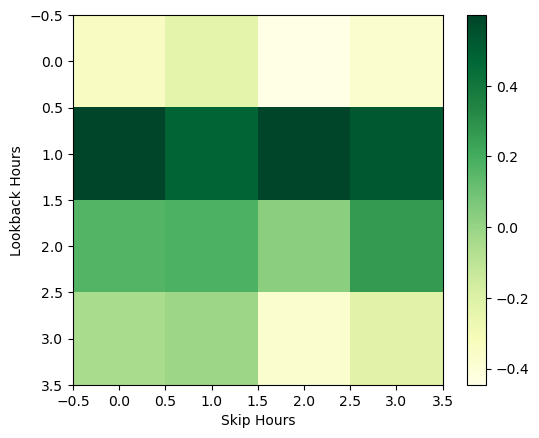

In [6]:
# Optimisation Step - Grid Search
# Used to find the optimal LOOKBACK_HOURS and SKIP_HOURS in the lookback_signal function

LOOKBACK_HOURS = [168, 336, 720, 2160]
SKIP_HOURS = [0, 6, 12, 24]

grid = [[0 for _ in range(len(SKIP_HOURS))] for _ in range(len(LOOKBACK_HOURS))]

ret = return_cal()
realised_vol = realised_vol_annual(ret)

for i, lookback in enumerate(LOOKBACK_HOURS):
    for j, skip in enumerate(SKIP_HOURS):
        coin_cum_return = lookback_signal(ret, lookback, skip)
        last_signal = final_signal(realised_vol, coin_cum_return)
        held_ranks = apply_rank_buffer(last_signal, rebal_freq_hours=72, rank_threshold=3)
        rebalanced_port = portfolio_construction(held_ranks, realised_vol, rebal_freq_hours=72)
        final_portfolio_returns, to = net_portfolio_returns(rebalanced_port, ret)
        final_portfolio_returns = final_portfolio_returns.dropna()

        grid[i][j] = sharpe(final_portfolio_returns)

plt.imshow(grid, cmap='YlGn')
plt.xlabel('Skip Hours')
plt.ylabel('Lookback Hours')
plt.colorbar()

In [7]:
grid

[[np.float64(-0.34710068656333015),
  np.float64(-0.23578085976843832),
  np.float64(-0.44570504602359046),
  np.float64(-0.37340060299869926)],
 [np.float64(0.5995895091031782),
  np.float64(0.479587364168905),
  np.float64(0.5977424488223322),
  np.float64(0.5249857486145304)],
 [np.float64(0.15870332623960473),
  np.float64(0.17738810423962645),
  np.float64(0.03192956465944098),
  np.float64(0.264436964998257)],
 [np.float64(-0.04652022573897082),
  np.float64(-0.013340742623344814),
  np.float64(-0.3769240400571818),
  np.float64(-0.22483707982776252)]]

<Axes: >

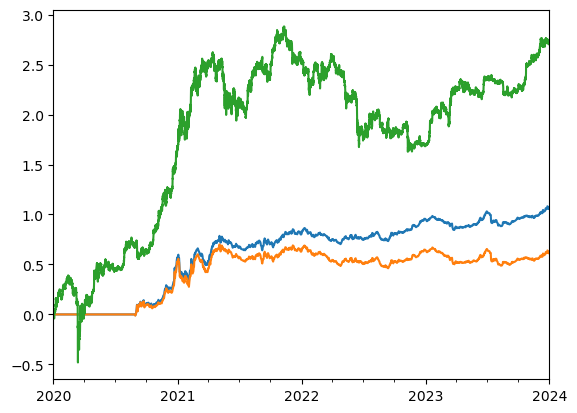

In [8]:
# Backtesting with optimal values derived from grid search: LOOKBACK_HOURS = 336, SKIP_HOURS = 0
ret = return_cal()
coin_cum_return = lookback_signal(ret, 336, 0)
realised_vol = realised_vol_annual(ret)
last_signal = final_signal(realised_vol, coin_cum_return)
held_ranks = apply_rank_buffer(last_signal, rebal_freq_hours=72, rank_threshold=3)
rebalanced_port = portfolio_construction(held_ranks, realised_vol, rebal_freq_hours=72)

# Gross vs Net Returns
# Blue line represent the gross portfolio returns, while Orange line represent net portfolio returns
Gross_portfolio_returns = gross_portfolio_returns(rebalanced_port, ret)
final_portfolio_returns, to = net_portfolio_returns(rebalanced_port, ret)
Gross_portfolio_returns.cumsum().plot()
final_portfolio_returns.cumsum().plot()
ret['BTCUSDT'].cumsum().plot()

In [9]:
# Quick analysis on the contributions of long_port and short_port

#The long leg was more consistently profitable, while the short leg added value during certain bearish / dislocated periods, but detracted over the full sample
long_port = rebalanced_port.clip(lower=0)
short_port = rebalanced_port.clip(upper=0)

long_returns = (long_port.shift(1) * ret).sum(axis=1)
short_returns = (short_port.shift(1) * ret).sum(axis=1)

long_returns = long_returns.dropna()
short_returns = short_returns.dropna()

long_returns = long_returns.resample('D').sum()
short_returns = short_returns.resample('D').sum()

<Axes: >

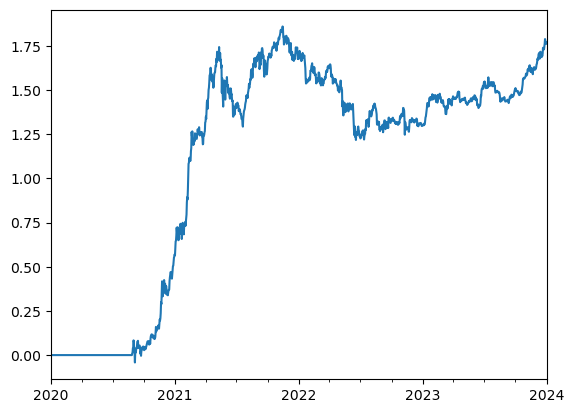

In [10]:
long_returns.cumsum().plot()

<Axes: >

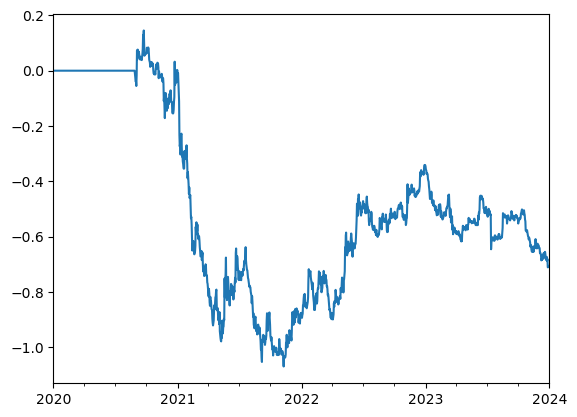

In [11]:
# The short_returns series is the P&L from actually being short, since the portfolio weights are negative
# We can see that the short leg performed particularly well from late 2021 to early 2023, which is inline with the crypto bear market
# This was due to the US Federal Reserve aggressive interest rate hike cycle, draining liquidity from risk-on assets like crypto, as well as the implosion of the Terra/LUNA ecosystem 
# From below, we see that the short leg has a negative sharpe over the full training and validation samples
# This means that its effectiveness is regime-dependent!
short_returns.cumsum().plot()

In [12]:
(long_returns.mean() * 252) / (long_returns.std() * np.sqrt(252))

np.float64(0.9697632877939693)

In [13]:
(short_returns.mean() * 252) / (short_returns.std() * np.sqrt(252))

np.float64(-0.39895257147558866)

In [14]:
# GROSS portfolio returns
gross_returns = Gross_portfolio_returns.dropna()

ann_return = gross_returns.mean() * 252       # hourly mean → annualised
ann_vol = gross_returns.std()  * np.sqrt(252)
sharpe = ann_return / ann_vol

cum = (1 + gross_returns).cumprod()
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

average_to = to.resample('D').sum().mean()

print("\n" + "=" * 40)
print("  Gross Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Average TO        : {average_to:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(gross_returns > 0).mean()*100:.1f}%")
print("=" * 40)

# NET portfolio returns
returns = final_portfolio_returns.dropna()

ann_return = returns.mean() * 252       # hourly mean → annualised
ann_vol = returns.std()  * np.sqrt(252)
sharpe = ann_return / ann_vol

cum = (1 + returns).cumprod()
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

average_to = to.resample('D').sum().mean()

print("\n" + "=" * 40)
print("  Net Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Average TO        : {average_to:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(returns > 0).mean()*100:.1f}%")
print("=" * 40)

# BTC returns
r = ret['BTCUSDT'].dropna()
r = r.groupby(r.index.normalize()).sum()

ann_return = r.mean() * 252       # hourly mean → annualised
ann_vol    = r.std()  * np.sqrt(252)
sharpe     = ann_return / ann_vol

cum        = (1 + r).cumprod()
max_dd     = ((cum - cum.cummax()) / cum.cummax()).min()

print("\n" + "=" * 40)
print("  BTC Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(r > 0).mean()*100:.1f}%")
print("=" * 40)


  Gross Performance Summary
  Annualised Return : 18.21%
  Annualised Vol    : 17.54%
  Sharpe Ratio      : 1.04
  Average TO        : 0.15
  Max Drawdown      : -24.50%
  Win Rate          : 43.7%

  Net Performance Summary
  Annualised Return : 10.52%
  Annualised Vol    : 17.54%
  Sharpe Ratio      : 0.60
  Average TO        : 0.15
  Max Drawdown      : -25.40%
  Win Rate          : 42.1%

  BTC Performance Summary
  Annualised Return : 46.95%
  Annualised Vol    : 57.06%
  Sharpe Ratio      : 0.82
  Max Drawdown      : -76.83%
  Win Rate          : 51.7%


In [15]:
# Correlation between NET portfolio returns and BTC returns
corr = r.corr(returns)
corr

np.float64(0.040651781202825824)

In [16]:
# Signifiance - OLS Regression
df = pd.concat([r, returns], axis=1)
df.columns = ['BTCUSDT', 'wml_return']
df = df.dropna()

X = sm.add_constant(df['BTCUSDT'].astype(float))
Y = df['wml_return'].astype(float)

results = sm.OLS(Y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             wml_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.417
Date:                Wed, 19 Aug 2026   Prob (F-statistic):              0.120
Time:                        10:54:26   Log-Likelihood:                 4513.8
No. Observations:                1462   AIC:                            -9024.
Df Residuals:                    1460   BIC:                            -9013.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.362      0.1

<Axes: >

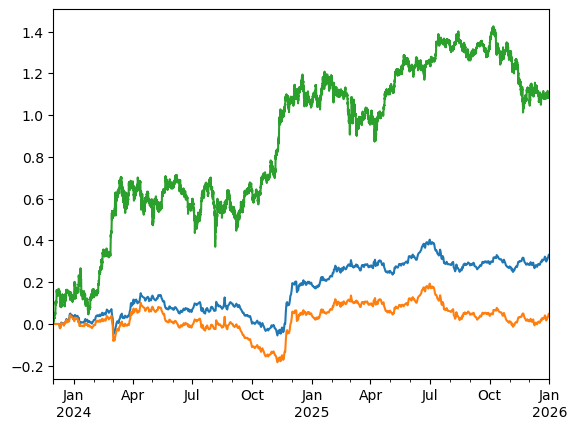

In [17]:
# Downloading approx 1 month of pre-2024 data for signal initialisation
def get_binance_px(symbol, freq, start_ts='2023-12-01', end_ts='2026-01-01'):
    data = client.get_historical_klines(symbol,freq,start_ts, end_ts) #fetch candlestick (OHLCV) data, W/O column names
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns=columns)
    
    #Binance stores timestamps as milliseconds since Jan 1, 1970 (POSIX time)
    #Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    #/1000 to convert milliseconds to seconds
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 

univ = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','DOTUSDT','XRPUSDT','LTCUSDT','LINKUSDT','XLMUSDT', 'BCHUSDT', 'TRXUSDT', 'XTZUSDT']

freq = '1h' #consider the freq as well? is 1h timeframe most optimal?

ret2 = return_cal()
coin_cum_return2 = lookback_signal(ret2, 336, 0)
realised_vol2 = realised_vol_annual(ret2)
last_signal2 = final_signal(realised_vol2, coin_cum_return2)
held_ranks2 = apply_rank_buffer(last_signal2, rebal_freq_hours=72, rank_threshold=3)
rebalanced_port2 = portfolio_construction(held_ranks2, realised_vol2, rebal_freq_hours=72)

# Gross vs Net Returns
gross_portfolio_returns2 = gross_portfolio_returns(rebalanced_port2, ret2)
final_portfolio_returns2, to2 = net_portfolio_returns(rebalanced_port2, ret2)
gross_portfolio_returns2.cumsum().plot()
final_portfolio_returns2.cumsum().plot()
ret2['BTCUSDT'].cumsum().plot()

In [18]:
# GROSS portfolio returns
gross_returns2 = gross_portfolio_returns2.dropna()

ann_return = gross_returns2.mean() * 252       # hourly mean → annualised
ann_vol = gross_returns2.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

cum = (1 + gross_returns2).cumprod()
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

average_to2 = to2.resample('D').sum().mean()

print("\n" + "=" * 40)
print("  Gross Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Average TO        : {average_to2:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(gross_returns2 > 0).mean()*100:.1f}%")
print("=" * 40)

# NET Strategy returns
returns2 = final_portfolio_returns2['2024-01-02 00:00:00+00:00': '2026-01-01 00:00:00+00:00'].dropna()

ann_return = returns2.mean() * 252       # hourly mean → annualised
ann_vol = returns2.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

cum = (1 + returns2).cumprod()
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

average_to2 = to2.resample('D').sum().mean()

print("\n" + "=" * 40)
print("  Net Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Average TO        : {average_to2:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(returns2 > 0).mean()*100:.1f}%")
print("=" * 40)

# BTC-returns
r2 = ret2['BTCUSDT'].dropna()
r2 = r2.groupby(r2.index.normalize()).sum()

ann_return = r2.mean() * 252       # hourly mean → annualised
ann_vol    = r2.std() * np.sqrt(252)
sharpe     = ann_return / ann_vol

cum        = (1 + r2).cumprod()
max_dd     = ((cum - cum.cummax()) / cum.cummax()).min()

print("\n" + "=" * 40)
print("  BTC Performance Summary")
print("=" * 40)
print(f"  Annualised Return : {ann_return*100:.2f}%")
print(f"  Annualised Vol    : {ann_vol*100:.2f}%")
print(f"  Sharpe Ratio      : {sharpe:.2f}")
print(f"  Max Drawdown      : {max_dd*100:.2f}%")
print(f"  Win Rate          : {(r2 > 0).mean()*100:.1f}%")
print("=" * 40)


  Gross Performance Summary
  Annualised Return : 10.94%
  Annualised Vol    : 16.08%
  Sharpe Ratio      : 0.68
  Average TO        : 0.15
  Max Drawdown      : -18.96%
  Win Rate          : 49.5%

  Net Performance Summary
  Annualised Return : 0.81%
  Annualised Vol    : 16.25%
  Sharpe Ratio      : 0.05
  Average TO        : 0.19
  Max Drawdown      : -25.41%
  Win Rate          : 48.4%

  BTC Performance Summary
  Annualised Return : 36.01%
  Annualised Vol    : 39.31%
  Sharpe Ratio      : 0.92
  Max Drawdown      : -31.94%
  Win Rate          : 52.4%


In [19]:
# Signifiance - OLS Regression (Validation)
df2 = pd.concat([r2, returns2], axis=1)
df2.columns = ['BTCUSDT', 'wml_return']
df2 = df2.dropna()

X2 = sm.add_constant(df2['BTCUSDT'].astype(float))
Y2 = df2['wml_return'].astype(float)

results2 = sm.OLS(Y2, X2).fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:             wml_return   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.549
Date:                Wed, 19 Aug 2026   Prob (F-statistic):             0.0107
Time:                        10:56:13   Log-Likelihood:                 2315.9
No. Observations:                 731   AIC:                            -4628.
Df Residuals:                     729   BIC:                            -4619.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        8.15e-05      0.000      0.216      0.8

In [20]:
long_port2 = rebalanced_port2.clip(lower=0)
short_port2 = rebalanced_port2.clip(upper=0)

long_returns2 = (long_port2.shift(1) * ret2).sum(axis=1)
short_returns2 = (short_port2.shift(1) * ret2).sum(axis=1)

long_returns2 = long_returns2.dropna()
short_returns2 = short_returns2.dropna()

long_returns2 = long_returns2.resample('D').sum()
short_returns2 = short_returns2.resample('D').sum()

In [21]:
# The lower validation results appear to reflect genuine out-of-sample deterioration and the effects of transaction cost
(long_returns2.mean() * 252) / (long_returns2.std() * np.sqrt(252))

np.float64(0.7931580723252922)

In [22]:
(short_returns2.mean() * 252) / (short_returns2.std() * np.sqrt(252))

np.float64(-0.32443450884237496)

<Axes: >

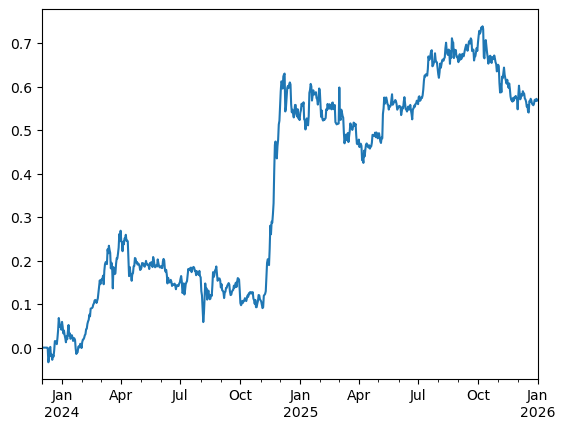

In [23]:
long_returns2.cumsum().plot()

<Axes: >

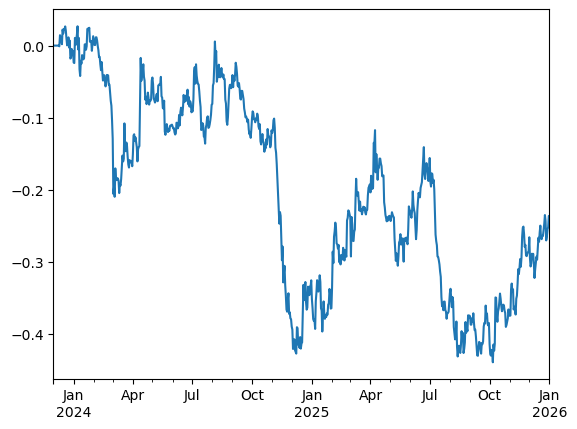

In [24]:
short_returns2.cumsum().plot()